In [3]:
# %matplotlib inline
import json
import random
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from sklearn.metrics import mean_squared_error, r2_score

# Dynamically resolve the data directory whether running from root or notebooks/
current_dir = Path.cwd()
if current_dir.name == "notebooks":
    DATA_ROOT = current_dir.parent / "data"
else:
    DATA_ROOT = current_dir / "scripts" / "statistical_analysis" / "data"

CSV_FILE = DATA_ROOT / "dataset_summary.csv"

print(f"Data directory set to: {DATA_ROOT}")

Data directory set to: /Users/neerajkaroshi/Desktop/Projects/chmv2_pipeline/scripts/statistical_analysis/data


Total Plots Analyzed : 100
Root Mean Sq Error   : 8.08 meters
Mean Bias Error      : 1.49 meters
Pearson R-squared    : -7.14


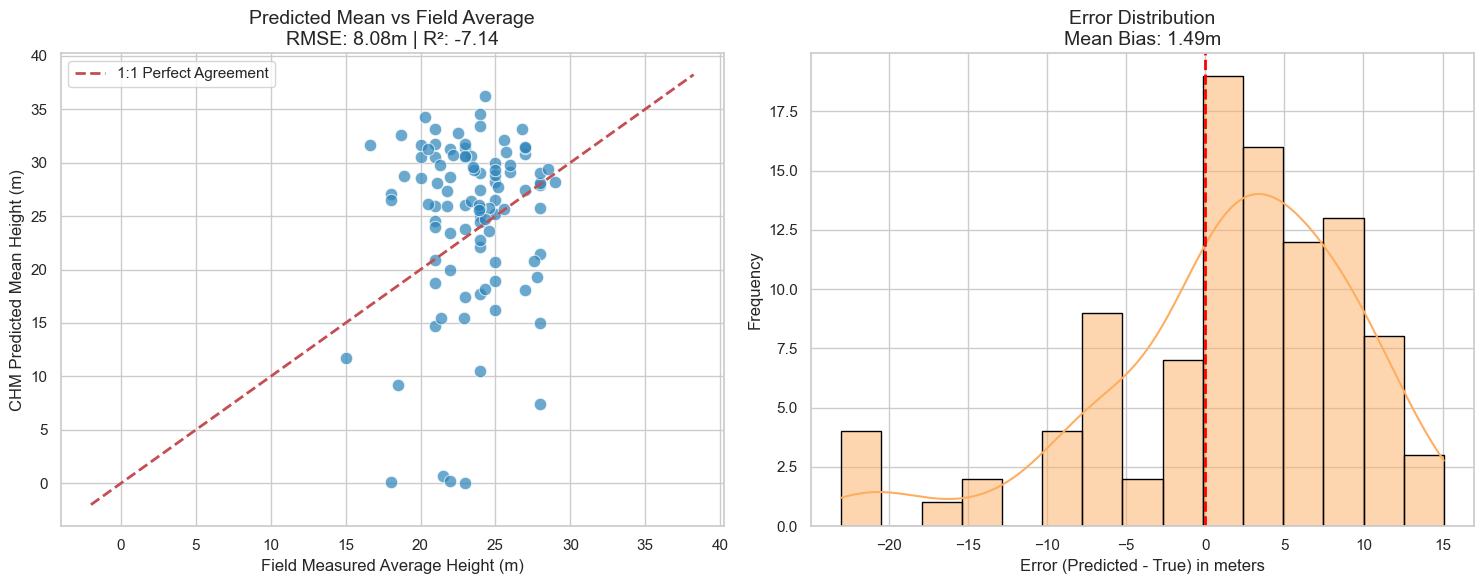

In [4]:
# Load the summary dataset
if not CSV_FILE.exists():
    print(f"Error: Could not find {CSV_FILE}. Run the extraction script first.")
else:
    df = pd.read_csv(CSV_FILE)
    df = df.dropna(subset=['h_avg_field', 'h_pred_mean'])
    
    y_true = df['h_avg_field']
    y_pred = df['h_pred_mean']
    
    # Calculate error metrics
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    bias = np.mean(y_pred - y_true)
    r2 = r2_score(y_true, y_pred)
    
    print(f"Total Plots Analyzed : {len(df)}")
    print(f"Root Mean Sq Error   : {rmse:.2f} meters")
    print(f"Mean Bias Error      : {bias:.2f} meters")
    print(f"Pearson R-squared    : {r2:.2f}")

    # Set up the visualization
    sns.set_theme(style="whitegrid")
    fig, axes = plt.subplots(1, 2, figsize=(15, 6))
    
    # 1. Scatter Plot (Predicted vs True)
    sns.scatterplot(x=y_true, y=y_pred, ax=axes[0], s=80, alpha=0.7, color='#2b83ba')
    
    # Add 1:1 reference line
    min_val = min(y_true.min(), y_pred.min()) - 2
    max_val = max(y_true.max(), y_pred.max()) + 2
    axes[0].plot([min_val, max_val], [min_val, max_val], 'r--', linewidth=2, label='1:1 Perfect Agreement')
    
    axes[0].set_title(f'Predicted Mean vs Field Average\nRMSE: {rmse:.2f}m | R²: {r2:.2f}', fontsize=14)
    axes[0].set_xlabel('Field Measured Average Height (m)', fontsize=12)
    axes[0].set_ylabel('CHM Predicted Mean Height (m)', fontsize=12)
    axes[0].legend()

    # 2. Residual Error Distribution
    errors = y_pred - y_true
    sns.histplot(errors, bins=15, kde=True, ax=axes[1], color='#fdae61', edgecolor='black')
    axes[1].axvline(0, color='red', linestyle='--', linewidth=2)
    
    axes[1].set_title(f'Error Distribution\nMean Bias: {bias:.2f}m', fontsize=14)
    axes[1].set_xlabel('Error (Predicted - True) in meters', fontsize=12)
    axes[1].set_ylabel('Frequency', fontsize=12)
    
    plt.tight_layout()
    plt.show()

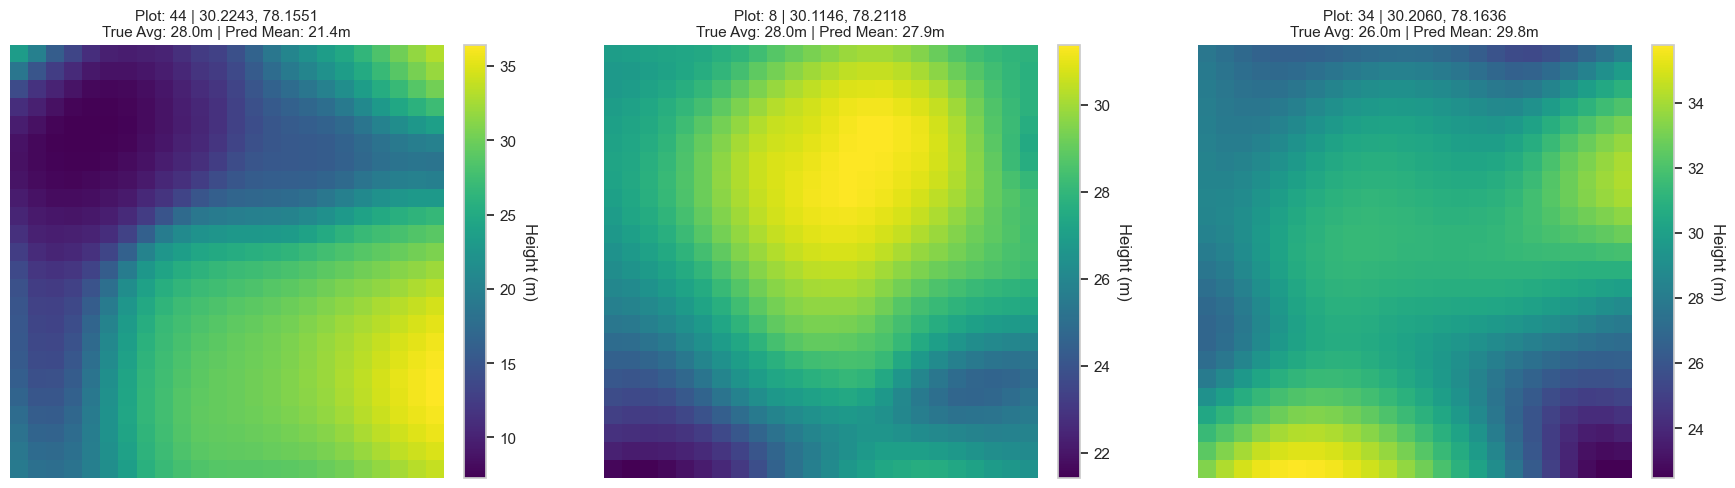

In [5]:
# Number of random plots to visualize
NUM_SAMPLES = 3

plot_dirs = [d for d in DATA_ROOT.iterdir() if d.is_dir() and d.name.startswith("plot_")]

if not plot_dirs:
    print("No individual plot directories found.")
else:
    samples = random.sample(plot_dirs, min(NUM_SAMPLES, len(plot_dirs)))
    
    fig, axes = plt.subplots(1, len(samples), figsize=(6 * len(samples), 5))
    if len(samples) == 1:
        axes = [axes]
        
    for i, pdir in enumerate(samples):
        npy_path = pdir / "pixels.npy"
        meta_path = pdir / "metadata.json"
        
        if not npy_path.exists() or not meta_path.exists():
            print(f"Missing data in {pdir.name}")
            continue
            
        # Load the 2D pixel array and metadata
        pixels = np.load(npy_path)
        with open(meta_path, 'r') as f:
            meta = json.load(f)
            
        h_true = meta['h_avg_field']
        h_pred = meta['h_pred_mean']
        
        # Render the canopy heatmap
        ax = axes[i]
        im = ax.imshow(pixels, cmap='viridis')
        cbar = plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
        cbar.set_label('Height (m)', rotation=270, labelpad=15)
        
        ax.set_title(f"Plot: {meta['sr']} | {meta['lat']:.4f}, {meta['lon']:.4f}\nTrue Avg: {h_true}m | Pred Mean: {h_pred:.1f}m", fontsize=11)
        ax.axis('off') 
        
    plt.tight_layout()
    plt.show()

/Users/neerajkaroshi/Desktop/Projects/chmv2_pipeline


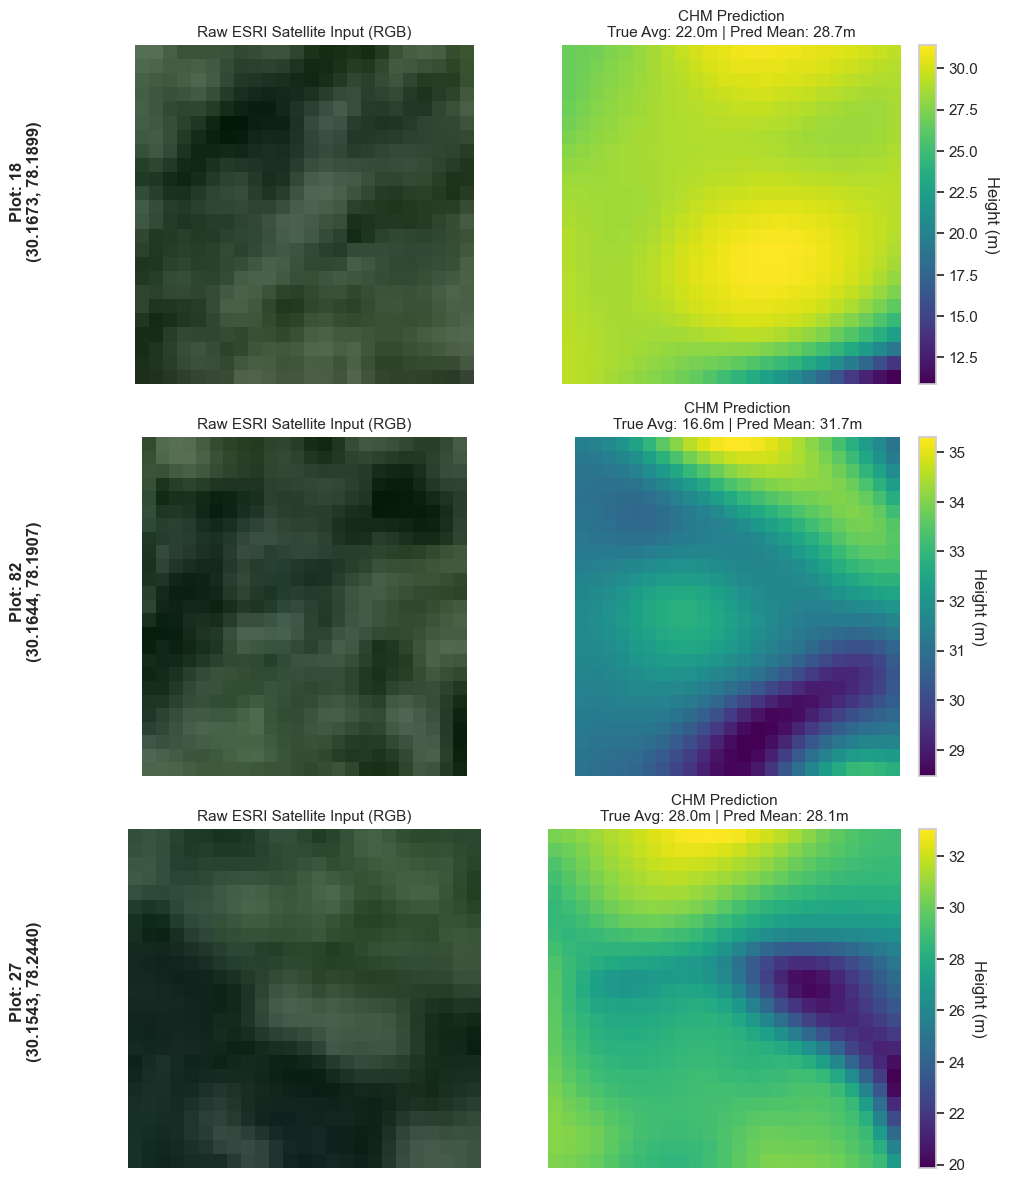

In [19]:
import json
import random
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image
from pathlib import Path

# Number of random plots to visualize
NUM_SAMPLES = 3

# Safely resolve the repository root directory

repo_root = current_dir.parent.parent.parent
print(repo_root)
# Define exact data paths using pathlib
DATA_ROOT = repo_root / "scripts" / "statistical_analysis" / "data"
ESRI_ROOT = repo_root / "data" / "input" / "esri_patches"

plot_dirs = [d for d in DATA_ROOT.iterdir() if d.is_dir() and d.name.startswith("plot_")]

if not plot_dirs:
    print(f"No individual plot directories found in {DATA_ROOT}")
else:
    samples = random.sample(plot_dirs, min(NUM_SAMPLES, len(plot_dirs)))
    
    # Create a grid: NUM_SAMPLES rows, 2 columns (Raw RGB, CHM Heatmap)
    fig, axes = plt.subplots(len(samples), 2, figsize=(10, 4 * len(samples)))
    
    # Handle case where there's only 1 sample (axes becomes 1D)
    if len(samples) == 1:
        axes = np.expand_dims(axes, axis=0)
        
    for i, pdir in enumerate(samples):
        npy_path = pdir / "pixels.npy"
        meta_path = pdir / "metadata.json"
        
        if not npy_path.exists() or not meta_path.exists():
            print(f"Missing data in {pdir.name}")
            continue
            
        # Load the CHM pixel array and metadata
        pixels = np.load(npy_path)
        with open(meta_path, 'r') as f:
            meta = json.load(f)
            
        h_true = meta['h_avg_field']
        h_pred = meta['h_pred_mean']
        tile_key = meta['tile_key']
        bbox = meta['bbox']
        
        # -----------------------------------------------------------
        # Column 1: Raw ESRI Optical Pixels
        # -----------------------------------------------------------
        ax_raw = axes[i, 0]
        
        # Construct the exact path to the PNG
        esri_path = ESRI_ROOT / f"esri_512_{tile_key}.png"
        
        if esri_path.exists():
            with Image.open(esri_path) as img:
                # Crop using the exact bounding box from metadata
                raw_crop = img.crop((bbox['col_min'], bbox['row_min'], bbox['col_max'], bbox['row_max']))
                ax_raw.imshow(raw_crop)
                ax_raw.set_title("Raw ESRI Satellite Input (RGB)", fontsize=11)
        else:
            ax_raw.text(0.5, 0.5, f"Raw Image Not Found\n{esri_path.name}", ha='center', va='center')
        
        ax_raw.axis('off')
        
        # -----------------------------------------------------------
        # Column 2: Predicted CHM Heatmap
        # -----------------------------------------------------------
        ax_chm = axes[i, 1]
        im = ax_chm.imshow(pixels, cmap='viridis')
        cbar = plt.colorbar(im, ax=ax_chm, fraction=0.046, pad=0.04)
        cbar.set_label('Height (m)', rotation=270, labelpad=15)
        
        ax_chm.set_title(f"CHM Prediction\nTrue Avg: {h_true}m | Pred Mean: {h_pred:.1f}m", fontsize=11)
        ax_chm.axis('off') 
        
        # Add Plot ID label to the far left of the row
        fig.text(0.02, 1 - (i + 0.5)/len(samples), 
                 f"Plot: {meta['sr']}\n({meta['lat']:.4f}, {meta['lon']:.4f})", 
                 va='center', ha='center', rotation=90, fontsize=12, fontweight='bold')
        
    # Adjust layout to leave room for the left labels
    plt.tight_layout(rect=[0.05, 0, 1, 1])
    plt.show()

In [24]:
# 1. Resolve the repository root (3 directories back as specified)
current_dir = Path.cwd()
repo_root = current_dir.parent.parent.parent



# 2. Define exact data paths using the resolved repo_root
DATA_ROOT = repo_root / "scripts" / "statistical_analysis" / "data"
ESRI_ROOT = repo_root / "data" / "input" / "esri_patches"
CSV_FILE = repo_root /  "scripts" / "statistical_analysis" / "dataset_summary.csv"



# 3. Load and process the dataframe
if not CSV_FILE.exists():
    print(f"File not found: {CSV_FILE}")
    print("Please ensure the extraction script has been run and the path is correct.")
else:
    # Load the dataframe
    df = pd.read_csv(CSV_FILE)
    
    # Drop any plots that failed to extract properly (missing values)
    df = df.dropna(subset=['h_avg_field', 'h_pred_mean']).copy()
    
    # Calculate the error metrics for each row
    # Error = Predicted - True (Positive means model overestimated, Negative means underestimated)
    df['Error'] = (df['h_pred_mean'] - df['h_avg_field']).round(2)
    df['Abs_Error'] = df['Error'].abs()
    
    # Select the most important columns to view
    display_cols = [
        'sr',             # Plot ID
        'h_avg_field',    # True Field Average (m)
        'h_pred_mean',    # Predicted CHM Mean (m)
        'Error',          # Deviation (Predicted - True)
        'Abs_Error',      # Absolute Error for sorting
        'h_pred_median',  # Predicted CHM Median
        'h_pred_std',     # Variation within the plot
        'n_pixels',       # Number of valid pixels used for the average
        'coverage_ratio'  # How much of the 12.5x12.5m box was valid
    ]
    
    # Filter to only requested columns that exist in the dataframe
    available_cols = [c for c in display_cols if c in df.columns]
    view_df = df[available_cols].copy()
    
    # Sort by Absolute Error to see where the model is most accurate first
    if 'Abs_Error' in view_df.columns:
        view_df = view_df.sort_values(by='Abs_Error', ascending=True)
    
    # Reset index for cleaner display
    view_df = view_df.reset_index(drop=True)
    
    print(f"Successfully loaded data for {len(view_df)} plots.\n")
    
    # Display the top 20 rows
    # Note: If running in a Jupyter Notebook, `display()` provides a nicely formatted HTML table.
    try:
        display(view_df.head(20))
    except NameError:
        # Fallback if running as a standard Python script in the terminal
        print(view_df.head(20).to_string())

Successfully loaded data for 100 plots.



,sr,h_avg_field,h_pred_mean,Error,Abs_Error,h_pred_median,h_pred_std,n_pixels,coverage_ratio
0,8,28.0,27.945749,-0.05,0.05,28.072435,2.254351,576,1.0
1,98,25.6,25.664785,0.06,0.06,26.228899,6.236966,576,1.0
2,90,21.0,20.914116,-0.09,0.09,23.479092,6.844951,576,1.0
3,27,28.0,28.115072,0.12,0.12,28.779491,2.714686,600,1.0
4,53,25.0,25.179544,0.18,0.18,26.376831,4.783776,576,1.0
5,40,27.0,27.451324,0.45,0.45,28.343105,4.932086,625,1.0
6,75,24.3,24.764730,0.46,0.46,25.718906,2.186580,528,1.0
7,60,24.0,24.476799,0.48,0.48,25.694767,4.614814,576,1.0
8,15,23.0,23.775597,0.78,0.78,24.630856,3.861097,600,1.0
9,39,29.0,28.209652,-0.79,0.79,28.764433,2.674011,576,1.0


In [25]:
df.head()

,sr,lat,lon,h_avg_field,h_pred_mean,h_pred_std,h_pred_min,h_pred_max,h_pred_median,n_pixels,coverage_ratio,tile_key,Error,Abs_Error
0,1,30.12714,78.25838,21.0,24.499262,2.599924,17.942537,28.829847,25.159393,360,1.0,z18_188058_108047,3.50,3.50
1,2,30.12591,78.25545,23.0,26.010990,4.510683,12.532547,31.474602,27.618654,576,1.0,z18_188055_108048,3.01,3.01
2,3,30.12571,78.25219,25.0,20.745291,5.028338,9.861094,29.927973,20.703838,576,1.0,z18_188053_108048,-4.25,4.25
3,4,30.12482,78.24848,18.9,28.757467,3.889994,22.155682,34.873505,28.836853,576,1.0,z18_188050_108049,9.86,9.86
4,5,30.12400,78.24399,22.9,15.444948,5.060161,7.229948,26.318604,14.754275,576,1.0,z18_188047_108049,-7.46,7.46


In [ ]:
df.describe("errors")

,sr,lat,lon,h_avg_field,h_pred_mean,h_pred_std,h_pred_min,h_pred_max,h_pred_median,n_pixels,coverage_ratio,Error,Abs_Error
count,100.000000,100.000000,100.000000,100.000000,100.000000,100.000000,100.000000,100.000000,100.000000,100.000000,100.0,100.000000,100.000000
mean,50.500000,30.149293,78.211126,23.441000,24.933210,3.933238,15.756540,31.583669,25.280687,568.020000,1.0,1.492600,6.339600
std,29.011492,0.048588,0.031590,2.848395,7.745077,2.281173,8.243645,7.606209,8.126430,57.236172,0.0,7.984876,5.041043
min,1.000000,30.087740,78.151560,15.000000,0.013797,0.003919,0.010483,0.029624,0.011972,312.000000,1.0,-22.990000,0.050000
25%,25.750000,30.113923,78.188120,21.375000,21.962568,2.393180,10.111027,30.361483,22.761500,576.000000,1.0,-1.905000,2.265000
50%,50.500000,30.129170,78.211570,23.900000,26.819621,3.472274,16.737852,33.139076,27.439062,576.000000,1.0,2.960000,5.645000
75%,75.250000,30.170430,78.235065,25.000000,30.479567,4.889684,22.028335,35.218224,31.131886,600.000000,1.0,7.010000,8.832500
max,100.000000,30.252340,78.276880,29.000000,36.220486,11.100377,30.345047,42.655716,36.581631,625.000000,1.0,15.080000,22.990000


             CHMv2 STATISTICAL EVALUATION             
Sample Size (N)        : 100 plots
Root Mean Square Error : 8.083 m
Mean Absolute Error    : 6.339 m
Mean Bias Error        : 1.492 m
Coefficient of Det (R²): -7.135
Pearson Correlation (r): 0.099 (p-value: 3.3e-01)

--- Error by Height Class (Saturation Check) ---


,Num Plots,Mean Bias (m),Std Dev (m)
Height_Class,,,
< 20m,11,5.17,10.56
20 - 24m,52,2.15,8.24
24 - 27m,26,1.42,4.93
> 27m,11,-5.14,6.86




--- Top 5 Worst Performing Plots (Outliers) ---


,sr,h_avg_field,h_pred_mean,Error,h_pred_std
40,41,23.0,0.013797,-22.986203,0.003919
93,94,22.0,0.200178,-21.799822,0.163684
91,92,21.5,0.698874,-20.801126,0.613552
5,6,28.0,7.460426,-20.539574,10.617382
41,42,18.0,0.121172,-17.878828,0.272323


/var/folders/nw/whndd4zx0yq8ggmr1g5hhd5m0000gn/T/ipykernel_55644/3252211139.py:96: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Height_Class', y='Error', data=df, ax=axes[1, 1], palette='Set2')



Saved diagnostic plots to: /Users/neerajkaroshi/Desktop/Projects/chmv2_pipeline/scripts/statistical_analysis/data/statistical_diagnostics.png


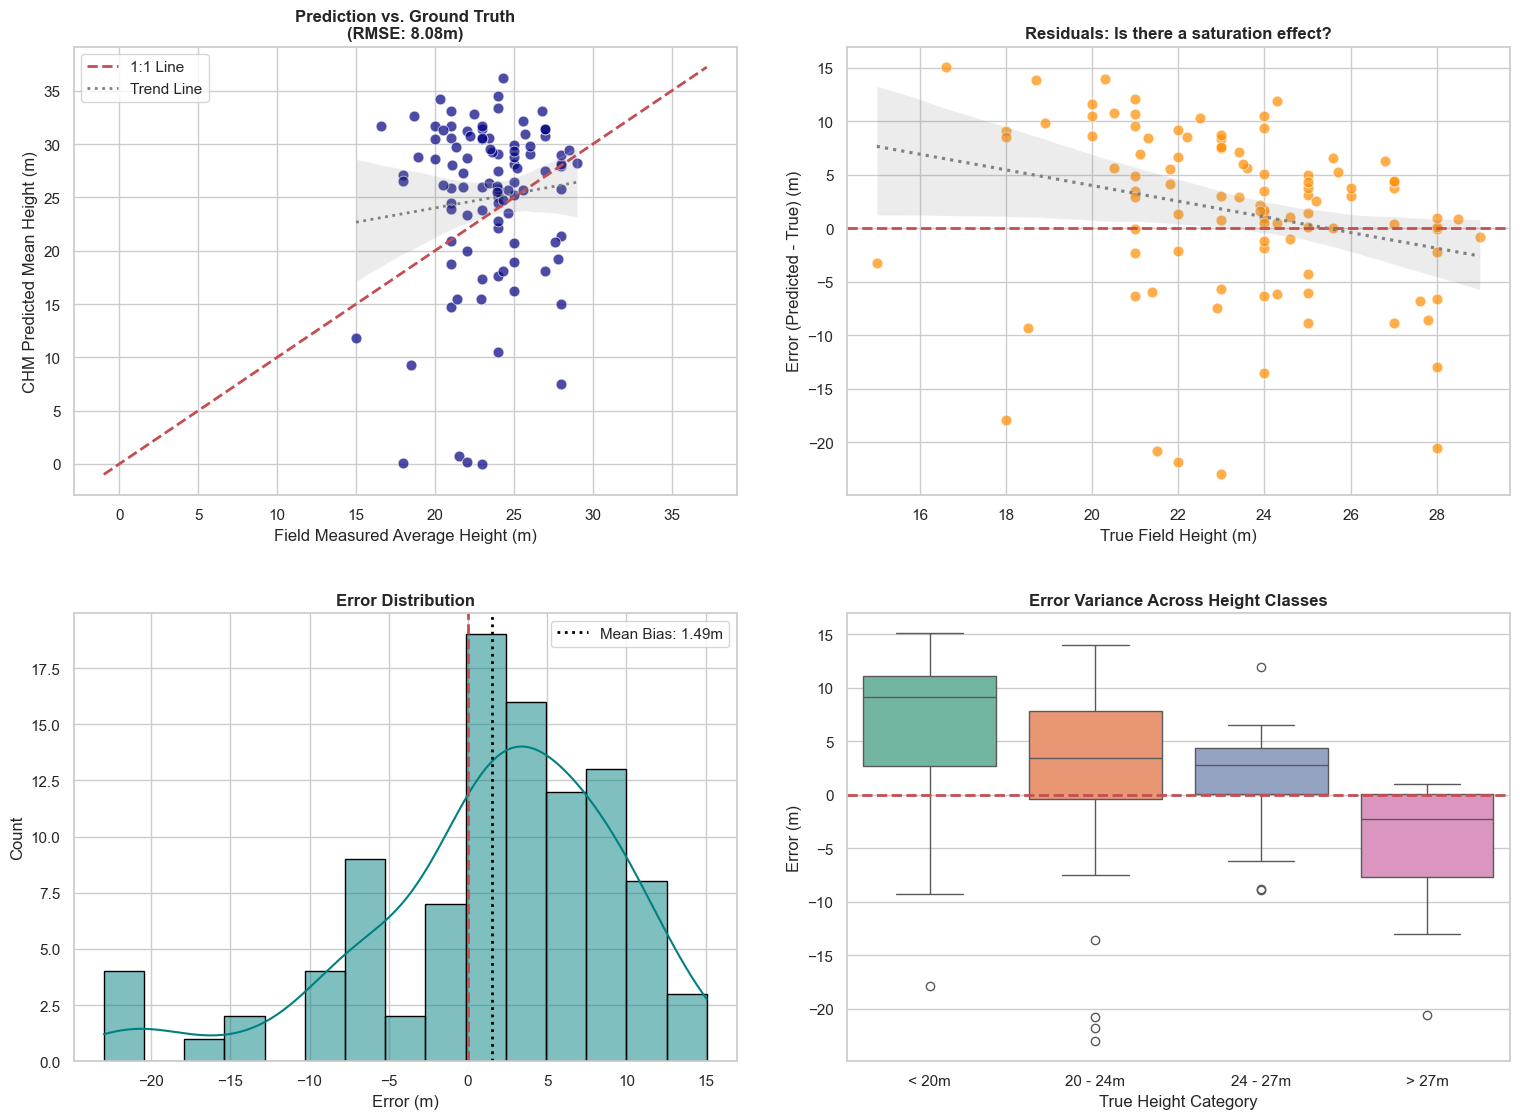

In [29]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from pathlib import Path

# --- 1. Path Resolution ---
current_dir = Path.cwd()
# Adjust this based on where your notebook is running (using your previous structure)
repo_root = current_dir.parent.parent.parent 
CSV_FILE = repo_root / "scripts" / "statistical_analysis" / "dataset_summary.csv"

if not CSV_FILE.exists():
    print(f"Cannot find data at: {CSV_FILE}")
else:
    # --- 2. Data Loading & Cleaning ---
    df = pd.read_csv(CSV_FILE)
    df = df.dropna(subset=['h_avg_field', 'h_pred_mean']).copy()
    
    y_true = df['h_avg_field']
    y_pred = df['h_pred_mean']
    
    # Calculate Error (Positive = Model Overestimated, Negative = Model Underestimated)
    df['Error'] = df['h_pred_mean'] - df['h_avg_field']
    df['Abs_Error'] = df['Error'].abs()

    # --- 3. Global Statistical Metrics ---
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    mae = mean_absolute_error(y_true, y_pred)
    bias = np.mean(df['Error'])
    r2 = r2_score(y_true, y_pred)
    pearson_r, p_value = stats.pearsonr(y_true, y_pred)

    print("======================================================")
    print("             CHMv2 STATISTICAL EVALUATION             ")
    print("======================================================")
    print(f"Sample Size (N)        : {len(df)} plots")
    print(f"Root Mean Square Error : {rmse:.3f} m")
    print(f"Mean Absolute Error    : {mae:.3f} m")
    print(f"Mean Bias Error        : {bias:.3f} m")
    print(f"Coefficient of Det (R²): {r2:.3f}")
    print(f"Pearson Correlation (r): {pearson_r:.3f} (p-value: {p_value:.1e})")
    print("======================================================\n")

    # --- 4. Stratified Analysis (Height Saturation) ---
    # Bin the data into height classes to see if the model struggles with tall/short trees
    bins = [0, 20, 24, 27, 40]
    labels = ['< 20m', '20 - 24m', '24 - 27m', '> 27m']
    df['Height_Class'] = pd.cut(df['h_avg_field'], bins=bins, labels=labels)
    
    print("--- Error by Height Class (Saturation Check) ---")
    class_stats = df.groupby('Height_Class', observed=True)['Error'].agg(['count', 'mean', 'std']).round(2)
    class_stats.columns = ['Num Plots', 'Mean Bias (m)', 'Std Dev (m)']
    display(class_stats)
    print("\n")

    # --- 5. Outlier Detection ---
    print("--- Top 5 Worst Performing Plots (Outliers) ---")
    outliers = df.sort_values(by='Abs_Error', ascending=False).head(5)
    display(outliers[['sr', 'h_avg_field', 'h_pred_mean', 'Error', 'h_pred_std']])

    # --- 6. Visual Diagnostics (4-Panel Chart) ---
    sns.set_theme(style="whitegrid")
    fig, axes = plt.subplots(2, 2, figsize=(16, 12))

    # A. Scatter Plot (1:1 Agreement)
    sns.scatterplot(x=y_true, y=y_pred, ax=axes[0, 0], s=60, alpha=0.7, color='navy')
    min_val = min(y_true.min(), y_pred.min()) - 1
    max_val = max(y_true.max(), y_pred.max()) + 1
    axes[0, 0].plot([min_val, max_val], [min_val, max_val], 'r--', lw=2, label='1:1 Line')
    sns.regplot(x=y_true, y=y_pred, ax=axes[0, 0], scatter=False, color='gray', line_kws={'ls':':', 'lw':2}, label='Trend Line')
    axes[0, 0].set_title(f'Prediction vs. Ground Truth\n(RMSE: {rmse:.2f}m)', fontweight='bold')
    axes[0, 0].set_xlabel('Field Measured Average Height (m)')
    axes[0, 0].set_ylabel('CHM Predicted Mean Height (m)')
    axes[0, 0].legend()

    # B. Residual Plot (Error vs True Height)
    sns.scatterplot(x=y_true, y=df['Error'], ax=axes[0, 1], s=60, alpha=0.7, color='darkorange')
    axes[0, 1].axhline(0, color='r', linestyle='--', lw=2)
    sns.regplot(x=y_true, y=df['Error'], ax=axes[0, 1], scatter=False, color='gray', line_kws={'ls':':'})
    axes[0, 1].set_title('Residuals: Is there a saturation effect?', fontweight='bold')
    axes[0, 1].set_xlabel('True Field Height (m)')
    axes[0, 1].set_ylabel('Error (Predicted - True) (m)')

    # C. Error Distribution
    sns.histplot(df['Error'], bins=15, kde=True, ax=axes[1, 0], color='teal', edgecolor='black')
    axes[1, 0].axvline(0, color='r', linestyle='--', lw=2)
    axes[1, 0].axvline(bias, color='black', linestyle=':', lw=2, label=f'Mean Bias: {bias:.2f}m')
    axes[1, 0].set_title('Error Distribution', fontweight='bold')
    axes[1, 0].set_xlabel('Error (m)')
    axes[1, 0].legend()

    # D. Boxplot of Error by Height Class
    sns.boxplot(x='Height_Class', y='Error', data=df, ax=axes[1, 1], palette='Set2')
    axes[1, 1].axhline(0, color='r', linestyle='--', lw=2)
    axes[1, 1].set_title('Error Variance Across Height Classes', fontweight='bold')
    axes[1, 1].set_xlabel('True Height Category')
    axes[1, 1].set_ylabel('Error (m)')

    plt.tight_layout(pad=3.0)
    
    # Save the figure to the same directory as the CSV
    out_img = DATA_ROOT / "statistical_diagnostics.png" if 'DATA_ROOT' in locals() else repo_root / "scripts" / "statistical_analysis" / "data" / "statistical_diagnostics.png"
    plt.savefig(out_img, dpi=300)
    print(f"\nSaved diagnostic plots to: {out_img}")
    plt.show()